# **Tarea 7. Usar APIs en la nube**

## **Alumna:** Isaura Yutsil Flores Escamilla

## **Matrícula:** A01796552

## **Objetivo:** El presente código tiene como objetivo consumir la API de Azure para la identificación de rostros.

In [ ]:
import json, os, requests

# Clave generada en nuestro portal de Azure
subscription_key = "2W7MrUzwasiAB9YtFInb4hsxHtOnOefuc50ha3Re09SsDIZuJzc2JQQJ99CCACBsN54XJ3w3AAAEACOGe6Mo"

# URL de la aplicación que queremos crear
face_api_url = "https://facerecognitionyutsilflores.cognitiveservices.azure.com" + '/face/v1.0/detect'

# URL de una imágen a utilizar
image_url = 'https://raw.githubusercontent.com/YutFlower/Computo_Nube/main/familia.png'


# Configuración de la clave a utilizar
headers = {'Ocp-Apim-Subscription-Key': subscription_key}


# Parámtros para la solicitud al servicio
params = {
    'returnFaceId': 'false',
    'returnFaceLandmarks': 'true',
    #'returnFaceAttributes': 'age, gender headPose, smile, facialHair, glasses, emotion',
}

# Llamada al servicio
response = requests.post(face_api_url, params=params, headers=headers, json={"url": image_url})
# Almacenar el resultado en formato JSON
faces = response.json()
# Mostrar el resultado como texto
json.dumps(faces)

'[{"faceRectangle": {"top": 614, "left": 745, "width": 530, "height": 530}, "faceLandmarks": {"pupilLeft": {"x": 917.7, "y": 741.0}, "pupilRight": {"x": 1145.9, "y": 787.8}, "noseTip": {"x": 1007.2, "y": 896.8}, "mouthLeft": {"x": 871.1, "y": 974.2}, "mouthRight": {"x": 1106.4, "y": 1020.5}, "eyebrowLeftOuter": {"x": 813.2, "y": 695.9}, "eyebrowLeftInner": {"x": 967.4, "y": 713.9}, "eyeLeftOuter": {"x": 881.8, "y": 736.5}, "eyeLeftTop": {"x": 918.8, "y": 731.7}, "eyeLeftBottom": {"x": 911.6, "y": 753.1}, "eyeLeftInner": {"x": 950.0, "y": 755.7}, "eyebrowRightInner": {"x": 1098.0, "y": 738.6}, "eyebrowRightOuter": {"x": 1240.8, "y": 766.8}, "eyeRightInner": {"x": 1107.7, "y": 787.2}, "eyeRightTop": {"x": 1143.2, "y": 778.3}, "eyeRightBottom": {"x": 1139.7, "y": 804.1}, "eyeRightOuter": {"x": 1178.4, "y": 798.2}, "noseRootLeft": {"x": 990.6, "y": 779.1}, "noseRootRight": {"x": 1058.6, "y": 790.1}, "noseLeftAlarTop": {"x": 968.1, "y": 842.6}, "noseRightAlarTop": {"x": 1065.4, "y": 858.3},

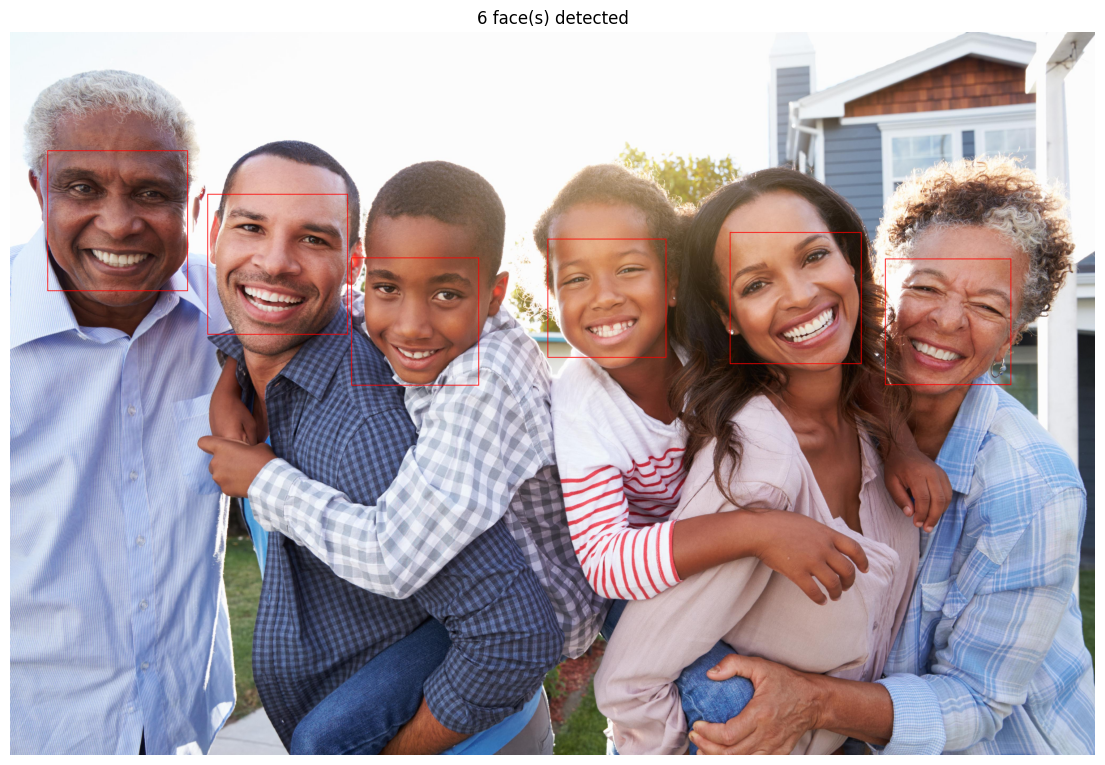

In [ ]:
from PIL import Image, ImageDraw
from io import BytesIO
import matplotlib.pyplot as plt

# 1. Descargar los datos de la imagen (Aseguramos que la descarga sea exitosa)
img_response = requests.get(image_url)

if img_response.status_code == 200:
    # 2. Crear el objeto de imagen desde los bytes descargados
    img = Image.open(BytesIO(img_response.content))

    # 3. Nuevo objeto para poder dibujar figuras sobre la foto
    draw = ImageDraw.Draw(img)

    # 4. Mostrar un rectángulo alrededor de las caras detectadas
    # Solo intentamos dibujar si 'faces' es una lista (respuesta exitosa de Azure)
    if isinstance(faces, list):
        for face in faces:
            rect = face['faceRectangle']
            left = rect['left']
            top = rect['top']
            right = left + rect['width']
            bottom = top + rect['height']

            draw.rectangle([left, top, right, bottom], outline='red', width=3)

        # 5. Formateo y despliegue de la imagen resultante
        plt.figure(figsize=(14, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{len(faces)} face(s) detected")
        plt.show()
    else:
        print("Error en la respuesta de la API:", faces)
else:
    print(f"No se pudo descargar la imagen. Código de estado: {img_response.status_code}")